In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

path = "/content/drive/MyDrive/Farming/wos_records.csv"

df = pd.read_csv(path, encoding="utf-8")

df = df.drop(columns=["Unnamed: 3"], errors="ignore")

In [4]:
df.columns
df.head(10)

,Indexed Date,Article Title,Abstract,UT (Unique ID)
0,2015-02-22,A Use Case in Semantic Modelling and Ranking f...,Agricultural decision support systems are an i...,WOS:000347622500018
1,2024-12-28,Smart Agricultural System Using Proximal Sensi...,The agricultural sector faces significant chal...,WOS:001375816400021
2,2019-01-01,LEAF: a process-based model of berry ripening ...,"Grapevines are extremely sensitive to climate,...",WOS:000794147000031
3,2025-03-01,A Knowledge-Driven Framework for a Decision Su...,Viticulture in Montenegro faces significant ch...,WOS:001431626800001
4,2021-03-18,Models Applied to Grapevine Pests: A Review,Simple SummaryMathematical models are develope...,WOS:000622615900001
5,2024-04-12,Volatile Organic Compound-Based Predictive Mod...,Smoke taint in wine has become a critical issu...,WOS:001192382000001
6,2025-12-16,Smart Irrigation with Fuzzy Decision Support S...,Efficient water management is a critical chall...,WOS:001635329000001
7,2024-11-26,A general DDE framework to describe insect pop...,Physiologically-based models area valuable too...,WOS:001358496800001
8,2010-01-01,Controlling ochratoxin A in the vineyard and w...,The chapter summarises the current availabilit...,WOS:000283543600015
9,2018-12-28,Development and Validation of a New Methodolog...,Assessing water status and optimizing irrigati...,WOS:000423533200001


In [5]:
df["text"] = (
    df["Article Title"].fillna("") + " " +
    df["Abstract"].fillna("")
).str.lower()

In [6]:
viticulture_terms = [
    "viticulture", "vineyard", "vineyards", "grapevine", "grapevines",
    "grape", "grapes", "wine", "vitis vinifera"
]

sensing_terms = [
    "remote sensing", "proximal sensing", "sensor", "sensors",
    "uav", "drone", "drones", "satellite", "multispectral",
    "hyperspectral", "lidar", "ndvi", "thermal imaging",
    "rgb", "spectroscopy", "imaging"
]

ai_ml_terms = [
    "machine learning", "artificial intelligence", "deep learning",
    "neural network", "random forest", "support vector machine",
    "svm", "cnn", "ann", "xgboost", "classification",
    "regression model", "predictive model", "algorithm"
]

dss_terms = [
    "decision support", "decision-support", "dss",
    "decision support system", "management system",
    "precision agriculture", "precision viticulture",
    "digital viticulture", "smart farming"
]

In [7]:
def contains_any(text, terms):
    return any(term in text for term in terms)

In [8]:
df["viticulture_match"] = df["text"].apply(lambda x: contains_any(x, viticulture_terms))
df["sensing_match"] = df["text"].apply(lambda x: contains_any(x, sensing_terms))
df["ai_ml_match"] = df["text"].apply(lambda x: contains_any(x, ai_ml_terms))
df["dss_match"] = df["text"].apply(lambda x: contains_any(x, dss_terms))

In [9]:
df["screening_score"] = (
    df["viticulture_match"].astype(int) +
    df["sensing_match"].astype(int) +
    df["ai_ml_match"].astype(int) +
    df["dss_match"].astype(int)
)

In [10]:
def screening_decision(row):
    if row["viticulture_match"] and row["sensing_match"] and (row["ai_ml_match"] or row["dss_match"]):
        return "Include"
    elif row["viticulture_match"] and row["screening_score"] >= 2:
        return "Review"
    else:
        return "Exclude"

df["Screening Decision"] = df.apply(screening_decision, axis=1)

In [11]:
df["Screening Decision"].value_counts()

,count
Screening Decision,
Include,867
Review,665
Exclude,275


In [12]:
# după ce ai calculat df["Screening Decision"]
df_inc = df[df["Screening Decision"] == "Include"].copy()

In [13]:
import pandas as pd
import numpy as np


# =========================
# 2. Use Include only
# =========================

df_inc = df[df["Screening Decision"] == "Include"].copy()

df_inc["text"] = (
    df_inc["Article Title"].fillna("") + " " +
    df_inc["Abstract"].fillna("")
).str.lower()


# =========================
# 3. WOS unique key
# =========================

def get_wos_key(row):
    for col in ["UT (Unique ID)", "UT", "WOS", "Accession Number"]:
        if col in row.index and pd.notna(row[col]):
            return str(row[col]).strip()
    return str(row["Article Title"]).lower().strip()

df_inc["WOS_key"] = df_inc.apply(get_wos_key, axis=1)


# =========================
# 4. Weighted categories
# =========================

weighted_categories = {

    "AI and Machine Learning": {
        "machine learning": 6,
        "artificial intelligence": 6,
        "deep learning": 6,
        "convolutional neural network": 6,
        "cnn": 5,
        "random forest": 5,
        "xgboost": 5,
        "support vector machine": 5,
        "svm": 4,
        "neural network": 4,
        "ann": 4,
        "transformer": 5,
        "vision transformer": 6,
        "ensemble learning": 5,
        "stacking": 5,
        "feature selection": 4,
        "classification model": 3,
        "regression model": 3,
        "predictive model": 3,
        "classification": 1,
        "regression": 1,
        "algorithm": 0.5
    },

    "Sensor and Spectral Technologies": {
        "hyperspectral": 6,
        "hyperspectral camera": 6,
        "hyperspectral imaging": 6,
        "multispectral": 5,
        "multispectral camera": 5,
        "spectroradiometer": 5,
        "spectrometer": 5,
        "thermal camera": 5,
        "thermal imaging": 5,
        "lidar": 5,
        "rgb camera": 3,
        "proximal sensing": 4,
        "remote sensing": 3,
        "uav": 3,
        "drone": 3,
        "sentinel": 4,
        "landsat": 4,
        "planetscope": 4,
        "google earth engine": 4,
        "ndvi": 1,
        "gndvi": 1,
        "savi": 1,
        "evi": 1,
        "vegetation index": 1,
        "sensor": 0.5,
        "sensors": 0.5
    },

    "Digital and Precision Viticulture": {
        "precision viticulture": 7,
        "digital viticulture": 7,
        "precision agriculture": 5,
        "site-specific": 5,
        "site specific": 5,
        "variable rate": 5,
        "variable-rate": 5,
        "precision spraying": 5,
        "precision irrigation": 5,
        "irrigation scheduling": 5,
        "management zone": 5,
        "vineyard zoning": 5,
        "prescription map": 5,
        "spatial variability": 3,
        "yield mapping": 4,
        "canopy management": 4
    },

    "Digital Technologies and Decision Support": {
        "iot": 6,
        "internet of things": 6,
        "digital twin": 6,
        "cloud computing": 5,
        "edge computing": 5,
        "blockchain": 5,
        "robotics": 5,
        "robot": 4,
        "autonomous robot": 6,
        "autonomous vehicle": 5,
        "mobile robot": 5,
        "automation": 4,
        "decision support": 5,
        "decision-support": 5,
        "decision support system": 6,
        "dss": 5,
        "early warning": 4,
        "forecasting system": 4,
        "recommendation system": 4,
        "farm management": 3
    }
}


# =========================
# 5. Score function
# =========================

def weighted_score(text, term_weights):
    text = str(text).lower()
    score = 0
    for term, weight in term_weights.items():
        score += text.count(term) * weight
    return score


for cat, term_weights in weighted_categories.items():
    df_inc[f"{cat}_score"] = df_inc["text"].apply(
        lambda x: weighted_score(x, term_weights)
    )


score_cols = [f"{cat}_score" for cat in weighted_categories.keys()]

df_inc["Max Score"] = df_inc[score_cols].max(axis=1)

df_inc["Main Category"] = df_inc[score_cols].idxmax(axis=1).str.replace("_score", "")

df_inc.loc[df_inc["Max Score"] == 0, "Main Category"] = "Unclassified"


# =========================
# 6. Select top N per category
# =========================

top_n = 40
min_score = 5

selected_list = []

for cat in weighted_categories.keys():

    temp = df_inc[
        (df_inc[f"{cat}_score"] >= min_score)
    ].copy()

    temp = temp.sort_values(
        by=f"{cat}_score",
        ascending=False
    )

    temp = temp.head(top_n)

    temp["Selected Category"] = cat

    selected_list.append(temp)

df_selected_raw = pd.concat(selected_list, ignore_index=True)


# =========================
# 7. Overlap metrics based on WOS_key
# =========================

total_rows = len(df_selected_raw)
unique_wos = df_selected_raw["WOS_key"].nunique()
duplicated_rows = total_rows - unique_wos

overlap_rate = duplicated_rows / total_rows * 100

print("Total selected rows:", total_rows)
print("Unique WOS articles:", unique_wos)
print("Duplicated category assignments:", duplicated_rows)
print("Overlap rate (%):", round(overlap_rate, 2))


# =========================
# 8. Pairwise overlap matrix
# =========================

category_sets = {}

for cat in weighted_categories.keys():
    category_sets[cat] = set(
        df_selected_raw[df_selected_raw["Selected Category"] == cat]["WOS_key"]
    )

overlap_matrix = pd.DataFrame(
    index=weighted_categories.keys(),
    columns=weighted_categories.keys()
)

for c1 in weighted_categories.keys():
    for c2 in weighted_categories.keys():
        overlap_matrix.loc[c1, c2] = len(category_sets[c1].intersection(category_sets[c2]))

overlap_matrix


# =========================
# 9. Unique allocation by strongest selected score
# =========================

df_selected_raw["Selected Category Score"] = df_selected_raw.apply(
    lambda row: row[f"{row['Selected Category']}_score"],
    axis=1
)

df_selected_unique = (
    df_selected_raw
    .sort_values(by=["WOS_key", "Selected Category Score"], ascending=[True, False])
    .drop_duplicates(subset="WOS_key", keep="first")
    .copy()
)

print("Unique final articles:", len(df_selected_unique))

final_summary = df_selected_unique["Selected Category"].value_counts().reset_index()
final_summary.columns = ["Selected Category", "Unique Articles"]
final_summary


# =========================
# 10. Export
# =========================

output_file = "/content/drive/MyDrive/Farming/wos_include_top40_weighted_overlap.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    df_inc.to_excel(writer, sheet_name="All Include Scored", index=False)

    df_selected_raw.to_excel(writer, sheet_name="Top40 Raw With Overlap", index=False)

    df_selected_unique.to_excel(writer, sheet_name="Top40 Unique", index=False)

    overlap_matrix.to_excel(writer, sheet_name="Overlap Matrix")

    final_summary.to_excel(writer, sheet_name="Final Summary", index=False)

    for cat in weighted_categories.keys():
        temp = df_selected_unique[
            df_selected_unique["Selected Category"] == cat
        ].copy()
        temp.to_excel(writer, sheet_name=cat[:31], index=False)

print("Saved:", output_file)



Total selected rows: 160
Unique WOS articles: 152
Duplicated category assignments: 8
Overlap rate (%): 5.0
Unique final articles: 152
Saved: /content/drive/MyDrive/Farming/wos_include_top40_weighted_overlap.xlsx


In [14]:
# =========================
# 12. Export separate TXT files
# =========================

import re

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", name).strip("_")

for cat in weighted_categories.keys():

    temp = df_selected_unique[
        df_selected_unique["Selected Category"] == cat
    ].copy()

    temp = temp.sort_values(
        by="Selected Category Score",
        ascending=False
    )

    file_name = safe_filename(cat)
    txt_path = f"/content/drive/MyDrive/Farming/{file_name}_unique_articles.txt"

    with open(txt_path, "w", encoding="utf-8") as f:

        f.write(cat + "\n")
        f.write("=" * len(cat) + "\n")
        f.write(f"Rule: Include only; Top 40; min_score = 5; unique by WOS_key\n")
        f.write(f"Number of unique articles: {len(temp)}\n\n")

        for i, (_, row) in enumerate(temp.iterrows(), start=1):

            f.write("=" * 120 + "\n")
            f.write(f"ARTICLE {i}\n")
            f.write("=" * 120 + "\n\n")

            f.write(f"Title: {row.get('Article Title','')}\n")
            f.write(f"WOS: {row.get('WOS_key','')}\n")
            f.write(f"Category: {cat}\n")
            f.write(f"Score: {row.get('Selected Category Score','')}\n\n")

            f.write("Abstract:\n")
            f.write(str(row.get("Abstract","")).strip() + "\n\n")

    print("Saved:", txt_path)

Saved: /content/drive/MyDrive/Farming/AI_and_Machine_Learning_unique_articles.txt
Saved: /content/drive/MyDrive/Farming/Sensor_and_Spectral_Technologies_unique_articles.txt
Saved: /content/drive/MyDrive/Farming/Digital_and_Precision_Viticulture_unique_articles.txt
Saved: /content/drive/MyDrive/Farming/Digital_Technologies_and_Decision_Support_unique_articles.txt


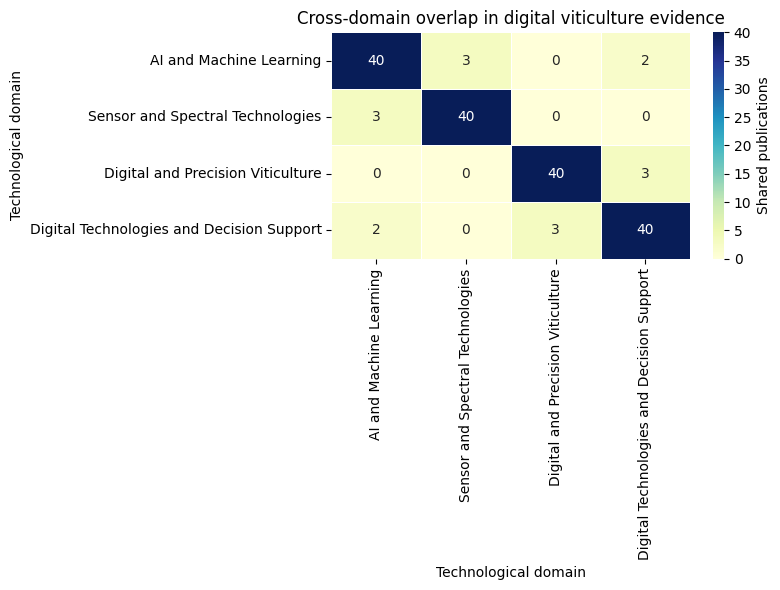

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    overlap_matrix.astype(int),
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Shared publications"}
)

plt.title("Cross-domain overlap in digital viticulture evidence")
plt.xlabel("Technological domain")
plt.ylabel("Technological domain")
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Farming/cross_domain_overlap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Farming/cross_domain_overlap.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculăm rank în fiecare categorie: